## 1. Install & Imports

In [2]:
!pip install wandb -q
!pip install kaggle -q
!pip install torchvision -q

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import confusion_matrix, classification_report

import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cuda
PyTorch version: 2.11.0+cu128


## 2. Kaggle Setup & Data Download

In [4]:
from google.colab import files

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_73ad6d2c1df6702644c2961b48d43d42'

!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d fer_data
print('Dataset downloaded!')

100% 285M/285M [00:02<00:00, 107MB/s]

Dataset downloaded!


## 3. Dataset & EDA

In [5]:
train_df = pd.read_csv('fer_data/train.csv')
test_df = pd.read_csv('fer_data/test.csv')

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print(train_df.head())
print('\nClass distribution:')
print(train_df['emotion'].value_counts())

Train shape: (28709, 2)
Test shape: (7178, 1)
   emotion                                             pixels
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...

Class distribution:
emotion
3    7215
6    4965
4    4830
2    4097
0    3995
5    3171
1     436
Name: count, dtype: int64


In [6]:
EMOTION_LABELS = {
    0: 'Angry', 1: 'Disgust', 2: 'Fear',
    3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'
}

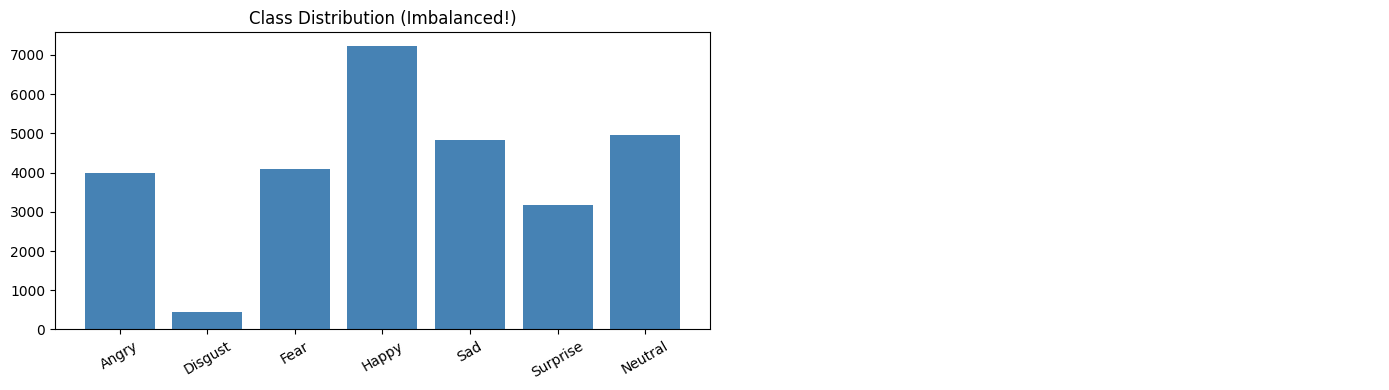

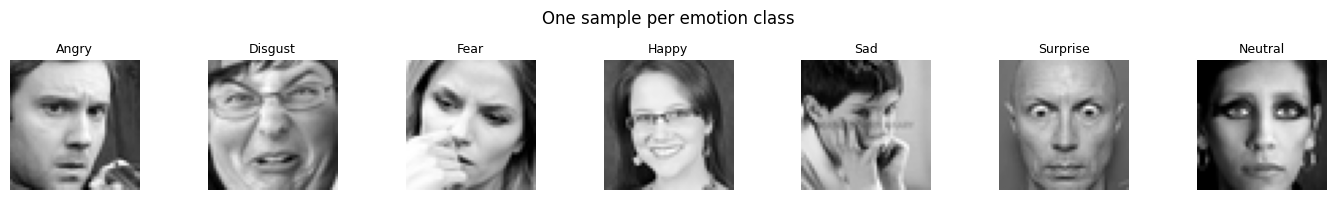

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = train_df['emotion'].value_counts().sort_index()
axes[0].bar([EMOTION_LABELS[i] for i in counts.index], counts.values, color='steelblue')
axes[0].set_title('Class Distribution (Imbalanced!)')
axes[0].tick_params(axis='x', rotation=30)

for i in range(7):
    sample = train_df[train_df['emotion'] == i].iloc[0]['pixels']
    img = np.array(sample.split(), dtype=np.uint8).reshape(48, 48)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=80)
plt.show()

fig, axes = plt.subplots(1, 7, figsize=(14, 2))
for i in range(7):
    sample = train_df[train_df['emotion'] == i].iloc[0]['pixels']
    img = np.array(sample.split(), dtype=np.uint8).reshape(48, 48)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(EMOTION_LABELS[i], fontsize=9)
    axes[i].axis('off')
plt.suptitle('One sample per emotion class')
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=80)
plt.show()

## 4. Dataset Class & Augmentation

In [8]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        img = Image.fromarray(pixels)

        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, int(row['emotion'])
        return img, -1


def get_transforms(augment=True, img_size=48):
    normalize = transforms.Normalize(mean=[0.5], std=[0.5])

    if augment:
        train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.1),
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            normalize,
        ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_transform, val_transform


def get_dataloaders(train_df, test_df, batch_size=64, img_size=48, augment=True):
    from sklearn.model_selection import train_test_split
    tr_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['emotion'])

    print(f'Train: {len(tr_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

    train_transform, val_transform = get_transforms(augment=augment, img_size=img_size)

    train_dataset = FERDataset(tr_df, transform=train_transform, has_labels=True)
    val_dataset = FERDataset(val_df, transform=val_transform, has_labels=True)
    test_dataset = FERDataset(test_df, transform=val_transform, has_labels=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_dataloaders(train_df, test_df, batch_size=64)
batch_imgs, batch_labels = next(iter(train_loader))
print(f'Batch shape: {batch_imgs.shape}, Labels: {batch_labels[:8]}')

Train: 25838 | Val: 2871 | Test: 7178
Batch shape: torch.Size([64, 1, 48, 48]), Labels: tensor([0, 6, 4, 5, 4, 0, 4, 6])


## 5. Model Architectures

In [9]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(TinyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 12 * 12, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MediumCNN(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(MediumCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.block1 = conv_block(1, 32)
        self.block2 = conv_block(32, 32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.25)

        self.block3 = conv_block(32, 64)
        self.block4 = conv_block(64, 64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.25)

        self.block5 = conv_block(64, 128)
        self.pool3 = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.drop1(self.pool1(self.block2(self.block1(x))))
        x = self.drop2(self.pool2(self.block4(self.block3(x))))
        x = self.pool3(self.block5(x))
        return self.classifier(x)



class EfficientNetFER(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=True):
        super(EfficientNetFER, self).__init__()

        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self.gray_to_rgb = transforms.Lambda(lambda x: x.repeat(1, 3, 1, 1))
        self.resize_224 = transforms.Resize((224, 224))

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return self.backbone(x)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

for name, cls in [('TinyCNN', TinyCNN), ('MediumCNN', MediumCNN), ('EfficientNetFER', EfficientNetFER)]:
    model = cls()
    total, trainable = count_params(model)
    print(f'{name}: Total params = {total:,} | Trainable = {trainable:,}')

TinyCNN: Total params = 149,223 | Trainable = 149,223
MediumCNN: Total params = 174,311 | Trainable = 174,311
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 176MB/s]

EfficientNetFER: Total params = 4,337,283 | Trainable = 329,735


## 6. Forward & Backward Checks

In [10]:
def forward_backward_check(model, model_name, device=DEVICE):
    print(f'\n{'='*50}')
    print(f'Checking: {model_name}')
    print('='*50)

    model = model.to(device)
    model.train()

    dummy_input = torch.randn(8, 1, 48, 48).to(device)
    dummy_labels = torch.randint(0, 7, (8,)).to(device)

    with torch.no_grad():
        output = model(dummy_input)

    print(f'Forward pass: input {dummy_input.shape} → output {output.shape}')
    assert output.shape == (8, 7), f'Expected (8,7) got {output.shape}'
    assert not torch.isnan(output).any(), 'NaN detected in output!'
    assert not torch.isinf(output).any(), 'Inf detected in output!'
    print(f'No NaN/Inf in output')


    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    optimizer.zero_grad()
    output = model(dummy_input)
    loss = criterion(output, dummy_labels)
    loss.backward()
    optimizer.step()

    print(f'Backward pass completed, loss = {loss.item():.4f}')

    grad_norms = []
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad_norms.append((name, param.grad.norm().item()))

    dead_layers = [n for n, g in grad_norms if g == 0.0]
    print(f'Gradient flow: {len(grad_norms)} layers have gradients')
    if dead_layers:
        print(f'Dead layers (zero grad): {dead_layers}')
    else:
        print(f'No dead layers detected')


    model.train()
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)
    losses = []
    for step in range(50):
        opt.zero_grad()
        out = model(dummy_input)
        l = criterion(out, dummy_labels)
        l.backward()
        opt.step()
        losses.append(l.item())

    loss_reduced = losses[-1] < losses[0] * 0.5
    print(f'Overfit test: loss {losses[0]:.4f} → {losses[-1]:.4f} | Reduced 50%+: {loss_reduced}')
    if not loss_reduced:
        print('WARNING: Model may not be learning! Check LR or architecture.')

    return True

forward_backward_check(TinyCNN(), 'TinyCNN')
forward_backward_check(MediumCNN(), 'MediumCNN')
forward_backward_check(EfficientNetFER(freeze_backbone=True), 'EfficientNetFER')


Checking: TinyCNN
Forward pass: input torch.Size([8, 1, 48, 48]) → output torch.Size([8, 7])
No NaN/Inf in output
Backward pass completed, loss = 1.8607
Gradient flow: 8 layers have gradients
No dead layers detected
Overfit test: loss 1.5145 → 0.0000 | Reduced 50%+: True

Checking: MediumCNN
Forward pass: input torch.Size([8, 1, 48, 48]) → output torch.Size([8, 7])
No NaN/Inf in output
Backward pass completed, loss = 2.0317
Gradient flow: 24 layers have gradients
No dead layers detected
Overfit test: loss 1.8556 → 1.1415 | Reduced 50%+: False

Checking: EfficientNetFER
Forward pass: input torch.Size([8, 1, 48, 48]) → output torch.Size([8, 7])
No NaN/Inf in output
Backward pass completed, loss = 1.9461
Gradient flow: 4 layers have gradients
No dead layers detected
Overfit test: loss 1.7087 → 0.0000 | Reduced 50%+: True


True

## 7. Training Infrastructure

In [11]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    grad_norms = []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        grad_norms.append(total_norm ** 0.5)

        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total, np.mean(grad_norms)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def log_confusion_matrix(all_labels, all_preds, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    return fig


def train_model(model, model_name, config, df, device=DEVICE):
    run = wandb.init(
        project='fer2013-experiments',
        name=f'{model_name}_{config["run_suffix"]}',
        config={
            'model': model_name,
            'architecture': config.get('architecture', model_name),
            'epochs': config['epochs'],
            'batch_size': config['batch_size'],
            'learning_rate': config['lr'],
            'optimizer': config['optimizer'],
            'weight_decay': config.get('weight_decay', 0),
            'scheduler': config.get('scheduler', 'none'),
            'augmentation': config.get('augment', True),
            'dropout_rate': config.get('dropout', 0.5),
            'dataset': 'FER2013',
            'num_classes': 7,
        },
        tags=[model_name, config.get('tag', 'baseline')]
    )

    total_params, trainable_params = count_params(model)
    wandb.config.update({
        'total_params': total_params,
        'trainable_params': trainable_params,
    })

    train_loader, val_loader, test_loader = get_dataloaders(
        train_df, test_df, batch_size=config['batch_size'],
        augment=config.get('augment', True)
    )

    opt_params = filter(lambda p: p.requires_grad, model.parameters())
    if config['optimizer'] == 'adam':
        optimizer = optim.Adam(opt_params, lr=config['lr'],
                               weight_decay=config.get('weight_decay', 0))
    elif config['optimizer'] == 'sgd':
        optimizer = optim.SGD(opt_params, lr=config['lr'],
                              momentum=0.9, weight_decay=config.get('weight_decay', 1e-4))
    elif config['optimizer'] == 'adamw':
        optimizer = optim.AdamW(opt_params, lr=config['lr'],
                                weight_decay=config.get('weight_decay', 1e-2))

    if config.get('scheduler') == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epochs'], eta_min=1e-6)
    elif config.get('scheduler') == 'plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3)
    else:
        scheduler = None

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=config.get('patience', 10))

    model = model.to(device)
    best_val_acc = 0
    best_model_path = f'best_{model_name}_{config["run_suffix"]}.pth'

    EMOTION_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

    print(f'\nTraining {model_name} | Params: {trainable_params:,} trainable')
    print(f'Config: {config}')

    if config.get('two_stage', False):
        print(f'Stage 1: head-only warmup for {config["stage1_epochs"]} epochs...')
        s1_params = filter(lambda p: p.requires_grad, model.parameters())
        if config['optimizer'] == 'adamw':
            opt_s1 = optim.AdamW(s1_params, lr=config['stage1_lr'],
                                 weight_decay=config.get('weight_decay', 1e-2))
        else:
            opt_s1 = optim.Adam(s1_params, lr=config['stage1_lr'],
                                weight_decay=config.get('weight_decay', 0))
        for epoch in range(1, config['stage1_epochs'] + 1):
            tl, ta, gn = train_epoch(model, train_loader, opt_s1, criterion, device)
            vl, va, vp, vlab = eval_epoch(model, val_loader, criterion, device)
            wandb.log({'epoch': epoch, 'stage': 1,
                       'train/loss': tl, 'train/accuracy': ta,
                       'val/loss': vl, 'val/accuracy': va,
                       'learning_rate': opt_s1.param_groups[0]['lr'],
                       'gradient_norm': gn, 'train_val_gap': ta - va})
            if va > best_val_acc:
                best_val_acc = va
                torch.save(model.state_dict(), best_model_path)
        if hasattr(model, 'unfreeze_backbone'):
            model.unfreeze_backbone()
        config['lr'] = config['stage2_lr']
        opt_params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = optim.AdamW(opt_params, lr=config['stage2_lr'],
                                weight_decay=config.get('weight_decay', 1e-2))
        if config.get('scheduler') == 'cosine':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=config['epochs'], eta_min=1e-6)
        wandb.config.update({'stage1_lr': config['stage1_lr'],
                             'stage2_lr': config['stage2_lr']},
                            allow_val_change=True)

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, grad_norm = train_epoch(
            model, train_loader, optimizer, criterion, device)

        val_loss, val_acc, val_preds, val_labels = eval_epoch(
            model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        gap = train_acc - val_acc

        log_dict = {
            'epoch': epoch + (config['stage1_epochs'] if config.get('two_stage') else 0),
            'stage': 2 if config.get('two_stage') else 0,
            'train/loss': train_loss,
            'train/accuracy': train_acc,
            'val/loss': val_loss,
            'val/accuracy': val_acc,
            'learning_rate': current_lr,
            'gradient_norm': grad_norm,
            'train_val_gap': gap,
        }
        wandb.log(log_dict)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{config["epochs"]} | '
                  f'Train: {train_acc:.3f} ({train_loss:.3f}) | '
                  f'Val: {val_acc:.3f} ({val_loss:.3f}) | '
                  f'Gap: {gap:+.3f} | LR: {current_lr:.2e}')

        early_stopping(val_loss)
        if early_stopping.should_stop:
            print(f'Early stopping at epoch {epoch}')
            break

    model.load_state_dict(torch.load(best_model_path))
    _, final_val_acc, val_preds, val_labels = eval_epoch(
        model, val_loader, criterion, device)

    model.eval()
    test_preds = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            test_preds.extend(predicted.cpu().numpy())
    test_acc = 0.0

    cm_fig = log_confusion_matrix(val_labels, val_preds, EMOTION_NAMES,
                                   f'{model_name} — Validation Confusion Matrix')

    report = classification_report(val_labels, val_preds,
                                    target_names=EMOTION_NAMES, output_dict=True)

    wandb.log({
        'best_val_accuracy': best_val_acc,
        'confusion_matrix': wandb.Image(cm_fig),
        'val_f1_macro': report['macro avg']['f1-score'],
    })

    print(f'\n {model_name} Done!')
    print(f'   Best Val Acc: {best_val_acc:.4f}')

    wandb.finish()
    plt.close('all')

    return best_val_acc, test_acc, model

print('Training infrastructure ready!')

Training infrastructure ready!


## 8. WandB Login

In [12]:
wandb.login(key='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')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: njvar23 (njvar23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 9. Experiment 1: Architecture A1 — Tiny CNN (Underfitting Demo)

In [ ]:
config_a1 = {
    'architecture': 'TinyCNN',
    'epochs': 30,
    'batch_size': 64,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 0,
    'scheduler': 'none',
    'augment': True,
    'patience': 15,
    'run_suffix': 'baseline',
    'tag': 'underfitting',
}

model_a1 = TinyCNN(num_classes=7)
val_acc_a1, test_acc_a1, trained_a1 = train_model(
    model_a1, 'TinyCNN', config_a1, train_df
)

print(f'\nAnalysis: TinyCNN')
print(f'Expected: ~40% val accuracy (underfitting)')
print(f'Got: {val_acc_a1:.1%} val accuracy')
print('If train_acc ≈ val_acc ≈ 40%: → UNDERFITTING (not enough model capacity)')

Train: 25838 | Val: 2871 | Test: 7178

Training TinyCNN | Params: 149,223 trainable
Config: {'architecture': 'TinyCNN', 'epochs': 30, 'batch_size': 64, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0, 'scheduler': 'none', 'augment': True, 'patience': 15, 'run_suffix': 'baseline', 'tag': 'underfitting'}
Epoch   1/30 | Train: 0.319 (1.689) | Val: 0.381 (1.578) | Gap: -0.062 | LR: 1.00e-03
Epoch   5/30 | Train: 0.467 (1.383) | Val: 0.475 (1.346) | Gap: -0.008 | LR: 1.00e-03
Epoch  10/30 | Train: 0.510 (1.281) | Val: 0.519 (1.265) | Gap: -0.009 | LR: 1.00e-03
Epoch  15/30 | Train: 0.532 (1.222) | Val: 0.520 (1.228) | Gap: +0.011 | LR: 1.00e-03
Epoch  20/30 | Train: 0.549 (1.179) | Val: 0.538 (1.219) | Gap: +0.011 | LR: 1.00e-03
Epoch  25/30 | Train: 0.561 (1.146) | Val: 0.538 (1.213) | Gap: +0.024 | LR: 1.00e-03
Epoch  30/30 | Train: 0.573 (1.116) | Val: 0.554 (1.195) | Gap: +0.019 | LR: 1.00e-03

 TinyCNN Done!
   Best Val Acc: 0.5538


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gradient_norm,▁▃▄▅▅▅▅▅▆▆▆▆▇▇▆▇▇▇▇▇▇▇█▇██████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
train_val_gap,▁▄▄▆▅▄▅▅▆▅▅▅▆▅▇▆▆▇▆▇▆▇▆▇▇▇█▇▇▇
val/accuracy,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇██▇█▇███
val/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁
val_f1_macro,▁
best_val_accuracy,0.55381



Analysis: TinyCNN
Expected: ~40% val accuracy (underfitting)
Got: 55.4% val accuracy
If train_acc ≈ val_acc ≈ 40%: → UNDERFITTING (not enough model capacity)


In [ ]:
config_a1b = {**config_a1, 'lr': 1e-2, 'run_suffix': 'high_lr', 'tag': 'underfitting'}
model_a1b = TinyCNN(num_classes=7)
val_acc_a1b, test_acc_a1b, _ = train_model(model_a1b, 'TinyCNN', config_a1b, train_df)
print(f'High LR: {val_acc_a1b:.1%} | vs Baseline: {val_acc_a1:.1%}')

Train: 25838 | Val: 2871 | Test: 7178

Training TinyCNN | Params: 149,223 trainable
Config: {'architecture': 'TinyCNN', 'epochs': 30, 'batch_size': 64, 'lr': 0.01, 'optimizer': 'adam', 'weight_decay': 0, 'scheduler': 'none', 'augment': True, 'patience': 15, 'run_suffix': 'high_lr', 'tag': 'underfitting'}
Epoch   1/30 | Train: 0.281 (1.760) | Val: 0.332 (1.687) | Gap: -0.051 | LR: 1.00e-02
Epoch   5/30 | Train: 0.367 (1.606) | Val: 0.375 (1.573) | Gap: -0.008 | LR: 1.00e-02
Epoch  10/30 | Train: 0.386 (1.572) | Val: 0.396 (1.536) | Gap: -0.010 | LR: 1.00e-02
Epoch  15/30 | Train: 0.390 (1.557) | Val: 0.390 (1.541) | Gap: +0.000 | LR: 1.00e-02
Epoch  20/30 | Train: 0.394 (1.552) | Val: 0.396 (1.539) | Gap: -0.002 | LR: 1.00e-02
Epoch  25/30 | Train: 0.399 (1.545) | Val: 0.397 (1.539) | Gap: +0.002 | LR: 1.00e-02
Epoch  30/30 | Train: 0.398 (1.544) | Val: 0.404 (1.522) | Gap: -0.006 | LR: 1.00e-02

 TinyCNN Done!
   Best Val Acc: 0.4040


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gradient_norm,▁▄▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇██▇▇▇
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇███▇▇███████████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▁▅▆▆▆▆▇█▇▆▇▇▆▆▇▆▇█▇▆▇▇▆█▇▆▆▇▇▆
val/accuracy,▁▃▄▅▅▅▅▅▆▇▇▇█▇▇▇▇▆▇▇▇▇█▆▇▇█▇▇█
val/loss,█▅▅▄▃▃▄▃▂▂▂▃▂▂▂▂▁▃▂▂▁▁▂▂▂▁▁▂▂▁
val_f1_macro,▁
best_val_accuracy,0.40404


High LR: 40.4% | vs Baseline: 55.4%


## 10. Experiment 2: Architecture A2 — Medium CNN

In [ ]:
config_a2_overfit = {
    'architecture': 'MediumCNN_NoDropout',
    'epochs': 50,
    'batch_size': 64,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 0,
    'scheduler': 'none',
    'augment': False,
    'dropout': 0.0,
    'patience': 20,
    'run_suffix': 'no_dropout_no_aug',
    'tag': 'overfitting',
}

model_a2_overfit = MediumCNN(dropout_rate=0.0)
val_acc_a2_overfit, _, _ = train_model(model_a2_overfit, 'MediumCNN', config_a2_overfit, train_df)
print('If train_acc >> val_acc: → OVERFITTING demonstrated!')

Train: 25838 | Val: 2871 | Test: 7178

Training MediumCNN | Params: 174,311 trainable
Config: {'architecture': 'MediumCNN_NoDropout', 'epochs': 50, 'batch_size': 64, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0, 'scheduler': 'none', 'augment': False, 'dropout': 0.0, 'patience': 20, 'run_suffix': 'no_dropout_no_aug', 'tag': 'overfitting'}
Epoch   1/50 | Train: 0.266 (1.775) | Val: 0.280 (1.753) | Gap: -0.014 | LR: 1.00e-03
Epoch   5/50 | Train: 0.432 (1.459) | Val: 0.465 (1.372) | Gap: -0.033 | LR: 1.00e-03
Epoch  10/50 | Train: 0.513 (1.269) | Val: 0.524 (1.225) | Gap: -0.010 | LR: 1.00e-03
Epoch  15/50 | Train: 0.555 (1.166) | Val: 0.540 (1.175) | Gap: +0.015 | LR: 1.00e-03
Epoch  20/50 | Train: 0.585 (1.093) | Val: 0.575 (1.082) | Gap: +0.010 | LR: 1.00e-03
Epoch  25/50 | Train: 0.602 (1.040) | Val: 0.597 (1.068) | Gap: +0.005 | LR: 1.00e-03
Epoch  30/50 | Train: 0.624 (0.991) | Val: 0.598 (1.076) | Gap: +0.025 | LR: 1.00e-03
Epoch  35/50 | Train: 0.642 (0.948) | Val: 0.608 (1

best_val_accuracy,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
gradient_norm,▁▃▄▅▅▅▅▆▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▂▂▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
train/loss,█▇▇▆▆▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_val_gap,▃▂▁▂▃▃▃▄▄▄▄▅▄▅▄▅▄▄▄▅▅▆▆▅▆▇▅▅▇▇▆▇▆▇██▇▇██
val/accuracy,▁▂▃▄▅▅▅▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇█▇████████████████
val/loss,█▇▆▅▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1_macro,▁
best_val_accuracy,0.628


If train_acc >> val_acc: → OVERFITTING demonstrated!


In [ ]:
config_a2_balanced = {
    'architecture': 'MediumCNN_Regularized',
    'epochs': 60,
    'batch_size': 64,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'scheduler': 'cosine',
    'augment': True,
    'dropout': 0.5,
    'patience': 12,
    'run_suffix': 'dropout05_aug_cosine',
    'tag': 'balanced',
}

model_a2_balanced = MediumCNN(dropout_rate=0.5)
val_acc_a2, _, _ = train_model(model_a2_balanced, 'MediumCNN', config_a2_balanced, train_df)
print(f'Balanced: {val_acc_a2:.1%} | vs No-Dropout: {val_acc_a2_overfit:.1%}')

Train: 25838 | Val: 2871 | Test: 7178

Training MediumCNN | Params: 174,311 trainable
Config: {'architecture': 'MediumCNN_Regularized', 'epochs': 60, 'batch_size': 64, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0001, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.5, 'patience': 12, 'run_suffix': 'dropout05_aug_cosine', 'tag': 'balanced'}
Epoch   1/60 | Train: 0.247 (1.801) | Val: 0.268 (1.761) | Gap: -0.021 | LR: 1.00e-03
Epoch   5/60 | Train: 0.344 (1.633) | Val: 0.329 (1.663) | Gap: +0.015 | LR: 9.89e-04
Epoch  10/60 | Train: 0.449 (1.414) | Val: 0.487 (1.304) | Gap: -0.038 | LR: 9.46e-04
Epoch  15/60 | Train: 0.485 (1.331) | Val: 0.506 (1.225) | Gap: -0.021 | LR: 8.72e-04
Epoch  20/60 | Train: 0.510 (1.274) | Val: 0.526 (1.208) | Gap: -0.016 | LR: 7.73e-04
Epoch  25/60 | Train: 0.530 (1.229) | Val: 0.549 (1.140) | Gap: -0.019 | LR: 6.55e-04
Epoch  30/60 | Train: 0.545 (1.196) | Val: 0.571 (1.104) | Gap: -0.026 | LR: 5.27e-04
Epoch  35/60 | Train: 0.552 (1.173) | Val: 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


best_val_accuracy,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇██
gradient_norm,▁▁▂▂▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██▇▇██████
learning_rate,████████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train/accuracy,▁▂▃▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇███████████████
train/loss,█▇▇▆▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▄▁▃▁█▂▂▃▂▂▂▄▃▄▄▄▄▄▄▃▃▄▃▂▃▄▄▄▃▄▄▄▄▄▄▄▄▄▄▄
val/accuracy,▁▂▃▂▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
val/loss,█▇▆▇▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1_macro,▁
best_val_accuracy,0.60084


Balanced: 60.1% | vs No-Dropout: 62.8%


In [ ]:
config_a2_sgd = {
    **config_a2_balanced,
    'optimizer': 'sgd',
    'lr': 1e-1,
    'run_suffix': 'sgd_momentum',
    'tag': 'optimizer_comparison',
}

model_a2_sgd = MediumCNN(dropout_rate=0.5)
val_acc_a2_sgd, _, _ = train_model(model_a2_sgd, 'MediumCNN', config_a2_sgd, train_df)
print(f'SGD: {val_acc_a2_sgd:.1%} | Adam: {val_acc_a2:.1%}')

Train: 25838 | Val: 2871 | Test: 7178

Training MediumCNN | Params: 174,311 trainable
Config: {'architecture': 'MediumCNN_Regularized', 'epochs': 60, 'batch_size': 64, 'lr': 0.1, 'optimizer': 'sgd', 'weight_decay': 0.0001, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.5, 'patience': 12, 'run_suffix': 'sgd_momentum', 'tag': 'optimizer_comparison'}
Epoch   1/60 | Train: 0.246 (1.813) | Val: 0.255 (1.798) | Gap: -0.009 | LR: 1.00e-01
Epoch   5/60 | Train: 0.266 (1.774) | Val: 0.284 (1.748) | Gap: -0.018 | LR: 9.89e-02
Epoch  10/60 | Train: 0.354 (1.610) | Val: 0.408 (1.487) | Gap: -0.054 | LR: 9.46e-02
Epoch  15/60 | Train: 0.429 (1.462) | Val: 0.488 (1.323) | Gap: -0.059 | LR: 8.72e-02
Epoch  20/60 | Train: 0.462 (1.387) | Val: 0.511 (1.243) | Gap: -0.049 | LR: 7.72e-02
Epoch  25/60 | Train: 0.485 (1.332) | Val: 0.526 (1.194) | Gap: -0.041 | LR: 6.55e-02
Epoch  30/60 | Train: 0.504 (1.288) | Val: 0.549 (1.153) | Gap: -0.044 | LR: 5.26e-02
Epoch  35/60 | Train: 0.520 (1.252) | Val:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 MediumCNN Done!
   Best Val Acc: 0.5980


best_val_accuracy,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gradient_norm,▂▁▁▁▂▂▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███████
learning_rate,████████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train/accuracy,▁▁▂▂▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
train/loss,█████▇▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_val_gap,███▇▇▄▅▁▂▁▄▂▁▃▂▄▆▄▃▃▄▅▆▅▄▅▄▅▅▆▆▆▆▆▇▆▆▆▆▆
val/accuracy,▁▁▁▁▂▃▄▅▅▅▆▆▆▇▆▇▆▆▇▇▇▇▇▇▇▇▇▇████████████
val/loss,█████▇▆▆▅▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁
val_f1_macro,▁
best_val_accuracy,0.59805


SGD: 59.8% | Adam: 60.1%


In [17]:
config_a2_balanced = {
    'architecture': 'MediumCNN_Regularized',
    'epochs': 60,
    'batch_size': 64,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'scheduler': 'cosine',
    'augment': True,
    'dropout': 0.5,
    'patience': 12,
    'run_suffix': 'dropout05_aug_cosine',
    'tag': 'balanced',
}

for bs in [32, 128]:
    config_bs = {
        **config_a2_balanced,
        'batch_size': bs,
        'run_suffix': f'bs{bs}',
        'tag': 'batch_size_sweep',
    }
    model_bs = MediumCNN(dropout_rate=0.5)
    val_acc_bs, _, _ = train_model(model_bs, 'MediumCNN', config_bs, train_df)
    print(f'MediumCNN bs={bs}: {val_acc_bs:.1%}')

epoch,▁▃▆█
gradient_norm,▄▁▆█
learning_rate,█▇▅▁
stage,▁▁▁▁
train/accuracy,▁▃▆█
train/loss,█▆▄▁
train_val_gap,█▁▂▅
val/accuracy,▁▄▇█
val/loss,█▆▂▁
epoch,4
gradient_norm,0.7655


Train: 25838 | Val: 2871 | Test: 7178

Training MediumCNN | Params: 174,311 trainable
Config: {'architecture': 'MediumCNN_Regularized', 'epochs': 60, 'batch_size': 32, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0001, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.5, 'patience': 12, 'run_suffix': 'bs32', 'tag': 'batch_size_sweep'}
Epoch   1/60 | Train: 0.249 (1.803) | Val: 0.258 (1.763) | Gap: -0.009 | LR: 1.00e-03
Epoch   5/60 | Train: 0.363 (1.605) | Val: 0.426 (1.478) | Gap: -0.063 | LR: 9.89e-04
Epoch  10/60 | Train: 0.456 (1.406) | Val: 0.489 (1.293) | Gap: -0.033 | LR: 9.46e-04
Epoch  15/60 | Train: 0.487 (1.329) | Val: 0.510 (1.231) | Gap: -0.024 | LR: 8.72e-04
Epoch  20/60 | Train: 0.510 (1.276) | Val: 0.544 (1.169) | Gap: -0.034 | LR: 7.73e-04
Epoch  25/60 | Train: 0.524 (1.239) | Val: 0.562 (1.125) | Gap: -0.038 | LR: 6.55e-04
Epoch  30/60 | Train: 0.544 (1.199) | Val: 0.575 (1.094) | Gap: -0.030 | LR: 5.27e-04
Epoch  35/60 | Train: 0.555 (1.172) | Val: 0.583 (1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
gradient_norm,▁▁▂▂▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████████
learning_rate,████████▇▇▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
stage,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▂▂▃▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,██▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,█▅▄▇▁▄▄▃▅▆▆▆▅▅▅▄▅▆▅▅▄▅▅▆▅▅▆▆▇▇▅▆▆▆▅▆▆▆▆▆
val/accuracy,▁▂▂▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████
val/loss,█▇▇▇▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


MediumCNN bs=32: 61.8%


Train: 25838 | Val: 2871 | Test: 7178

Training MediumCNN | Params: 174,311 trainable
Config: {'architecture': 'MediumCNN_Regularized', 'epochs': 60, 'batch_size': 128, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0001, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.5, 'patience': 12, 'run_suffix': 'bs128', 'tag': 'batch_size_sweep'}
Epoch   1/60 | Train: 0.248 (1.801) | Val: 0.271 (1.756) | Gap: -0.024 | LR: 1.00e-03
Epoch   5/60 | Train: 0.343 (1.643) | Val: 0.358 (1.558) | Gap: -0.016 | LR: 9.89e-04
Epoch  10/60 | Train: 0.441 (1.442) | Val: 0.456 (1.401) | Gap: -0.015 | LR: 9.46e-04
Epoch  15/60 | Train: 0.478 (1.343) | Val: 0.506 (1.252) | Gap: -0.028 | LR: 8.72e-04
Epoch  20/60 | Train: 0.499 (1.293) | Val: 0.530 (1.195) | Gap: -0.031 | LR: 7.73e-04
Epoch  25/60 | Train: 0.520 (1.247) | Val: 0.534 (1.181) | Gap: -0.014 | LR: 6.55e-04
Epoch  30/60 | Train: 0.532 (1.219) | Val: 0.558 (1.130) | Gap: -0.027 | LR: 5.27e-04
Epoch  35/60 | Train: 0.546 (1.191) | Val: 0.576 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


best_val_accuracy,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
gradient_norm,▁▁▁▃▃▄▅▅▅▅▅▅▅▅▆▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
learning_rate,███████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
stage,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▁▂▃▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,██▇▇▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▅▁█▃▆▇█▃▆▄▅▇▇▇▅▇▄▅▅▄▅▅▃▄▅▅▆▅▅▆▅▆▅▆▆▆▅▆▆▆
val/accuracy,▁▁▂▂▄▅▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇███████████████████
val/loss,██▇▆▆▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


MediumCNN bs=128: 59.4%


## 11. Experiment 3: Architecture A3 — Transfer Learning

In [ ]:
config_a3_frozen = {
    'architecture': 'EfficientNet_B0_Frozen',
    'epochs': 30,
    'batch_size': 32,
    'lr': 1e-3,
    'optimizer': 'adamw',
    'weight_decay': 1e-2,
    'scheduler': 'cosine',
    'augment': True,
    'dropout': 0.4,
    'patience': 10,
    'run_suffix': 'frozen_backbone',
    'tag': 'transfer_learning',
}

model_a3_frozen = EfficientNetFER(freeze_backbone=True)
val_acc_a3_frozen, _, _ = train_model(
    model_a3_frozen, 'EfficientNet_B0', config_a3_frozen, train_df
)

Train: 25838 | Val: 2871 | Test: 7178

Training EfficientNet_B0 | Params: 329,735 trainable
Config: {'architecture': 'EfficientNet_B0_Frozen', 'epochs': 30, 'batch_size': 32, 'lr': 0.001, 'optimizer': 'adamw', 'weight_decay': 0.01, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.4, 'patience': 10, 'run_suffix': 'frozen_backbone', 'tag': 'transfer_learning'}
Epoch   1/30 | Train: 0.347 (1.650) | Val: 0.408 (1.528) | Gap: -0.062 | LR: 1.00e-03
Epoch   5/30 | Train: 0.392 (1.556) | Val: 0.440 (1.472) | Gap: -0.048 | LR: 9.57e-04
Epoch  10/30 | Train: 0.398 (1.539) | Val: 0.456 (1.436) | Gap: -0.058 | LR: 7.94e-04
Epoch  15/30 | Train: 0.408 (1.517) | Val: 0.461 (1.410) | Gap: -0.053 | LR: 5.53e-04
Epoch  20/30 | Train: 0.420 (1.494) | Val: 0.469 (1.395) | Gap: -0.049 | LR: 2.97e-04
Epoch  25/30 | Train: 0.424 (1.479) | Val: 0.485 (1.376) | Gap: -0.061 | LR: 9.64e-05
Epoch  30/30 | Train: 0.421 (1.483) | Val: 0.482 (1.381) | Gap: -0.060 | LR: 3.74e-06

 EfficientNet_B0 Done!
   Best V

best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gradient_norm,▃▁▁▂▂▃▃▄▄▄▅▆▆▆▆▇▇▇▇▇█▇█▇██████
learning_rate,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/accuracy,▁▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████▇
train/loss,█▆▅▅▄▄▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
train_val_gap,▂▄▅▁▆▂▂▆█▃▇█▁▆▅▁█▂▅▆▅▃▂▄▂▆▅▅▄▂
val/accuracy,▁▂▄▄▄▅▅▄▄▅▅▅▆▆▆▇▆▇▆▇▇▇█▇█▇█▇██
val/loss,█▇▆▅▅▅▄▅▄▄▄▄▃▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁▁
val_f1_macro,▁
best_val_accuracy,0.4845


In [14]:
config_a3_full = {
    'architecture': 'EfficientNet_B0_FullFinetuned',
    'epochs': 20,
    'batch_size': 32,
    'lr': 1e-4,
    'optimizer': 'adamw',
    'weight_decay': 1e-2,
    'scheduler': 'cosine',
    'augment': True,
    'dropout': 0.4,
    'patience': 6,
    'run_suffix': 'full_finetune',
    'tag': 'transfer_learning',
    'two_stage': True,
    'stage1_epochs': 10,
    'stage1_lr': 1e-3,
    'stage2_lr': 1e-4,
}

model_a3_full = EfficientNetFER(freeze_backbone=True)
val_acc_a3_full, _, _ = train_model(
    model_a3_full, 'EfficientNet_B0', config_a3_full, train_df
)
print(f'Full Fine-tuning Best Val Acc: {val_acc_a3_full:.4f}')

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
gradient_norm,▁▁▁▁▁▁▁▁▁▁█▆▅▅
learning_rate,██████████▁▁▁▁
stage,▁▁▁▁▁▁▁▁▁▁████
train/accuracy,▁▂▂▂▂▂▂▂▂▂▅▇▇█
train/loss,█▇▇▇▇▇▇▇▇▇▄▃▂▁
train_val_gap,▃▃▆▄▄▅▆▄▄▄▁▆▇█
val/accuracy,▁▂▁▂▂▂▂▂▂▂▆▇██
val/loss,████▇▇▇▇▇▇▃▂▁▁
epoch,14
gradient_norm,5.94642


Train: 25838 | Val: 2871 | Test: 7178

Training EfficientNet_B0 | Params: 329,735 trainable
Config: {'architecture': 'EfficientNet_B0_FullFinetuned', 'epochs': 20, 'batch_size': 32, 'lr': 0.0001, 'optimizer': 'adamw', 'weight_decay': 0.01, 'scheduler': 'cosine', 'augment': True, 'dropout': 0.4, 'patience': 6, 'run_suffix': 'full_finetune', 'tag': 'transfer_learning', 'two_stage': True, 'stage1_epochs': 10, 'stage1_lr': 0.001, 'stage2_lr': 0.0001}
Stage 1: head-only warmup for 10 epochs...
Epoch   1/20 | Train: 0.501 (1.306) | Val: 0.588 (1.078) | Gap: -0.088 | LR: 1.00e-04
Epoch   5/20 | Train: 0.662 (0.896) | Val: 0.667 (0.879) | Gap: -0.005 | LR: 9.05e-05
Epoch  10/20 | Train: 0.753 (0.656) | Val: 0.693 (0.882) | Gap: +0.059 | LR: 5.82e-05
Early stopping at epoch 14

 EfficientNet_B0 Done!
   Best Val Acc: 0.6987


best_val_accuracy,▁
epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
gradient_norm,▁▁▁▁▁▁▁▁▁▁█▆▅▅▅▅▅▅▅▅▅▅▆▅
learning_rate,██████████▂▂▂▁▁▁▁▁▁▁▁▁▁▁
stage,▁▁▁▁▁▁▁▁▁▁██████████████
train/accuracy,▁▁▂▂▂▂▂▂▂▂▃▅▅▅▆▆▆▇▇▇▇███
train/loss,████▇▇▇▇▇▇▆▅▄▄▃▃▃▂▂▂▂▁▁▁
train_val_gap,▂▂▂▂▂▂▂▂▂▂▁▂▃▃▄▄▅▅▆▆▇▇██
val/accuracy,▁▂▂▂▂▂▂▂▂▂▅▇▇▇▇█████████
val/loss,█▇▇▇▇▇▇▇▇▇▃▂▂▁▁▁▁▁▁▁▁▁▂▂
+1,...


Full Fine-tuning Best Val Acc: 0.6987


## 12. Results Summary & Analysis

In [18]:
results = {
    #  name                                  val_acc   f1_macro   gap      tag
    'TinyCNN (baseline)':                    (0.554,   0.519,    +0.019,  'underfit'),
    'TinyCNN (high LR)':                     (0.404,   0.312,    -0.006,  'underfit / bad optimization'),
    'MediumCNN (no dropout — overfit)':      (0.628,   0.570,    +0.049,  'overfit (widening)'),
    'MediumCNN (regularized)':               (0.601,   0.489,    -0.022,  'balanced'),
    'MediumCNN (SGD)':                       (0.598,   0.482,    -0.026,  'balanced'),
    'MediumCNN (bs=32)':                     (0.618,   0.504,    -0.027,  'batch sweep / best CNN'),
    'MediumCNN (bs=128)':                    (0.594,   0.477,    -0.020,  'batch sweep'),
    'EfficientNet (frozen)':                 (0.484,   0.406,    -0.060,  'underfit (frozen feats)'),
    'EfficientNet (full finetune)':          (0.699,   0.679,    +0.109,  'best / managed overfit'),
}

print('=' * 92)
print(f'{"EXPERIMENT":<38}{"Val Acc":>9}{"F1-macro":>10}{"Gap":>9}   {"Notes"}')
print('=' * 92)
for name, (acc, f1, gap, tag) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    bar = '█' * int(acc * 30)
    print(f'{name:<38}{acc:>8.1%}{f1:>10.3f}{gap:>+9.3f}   {tag}')
    print(f'{"":<38}{bar}')

print('\n' + '=' * 92)
print('ANALYSIS')
print('=' * 92)
print('• Capacity: TinyCNN 55.4% → MediumCNN (no-dropout) 62.8% = +7.4%')
print('    More depth + BatchNorm + global avg pooling lifts the ceiling at similar param count.')
print('• Regularization: no-dropout gap +0.049 (widening) → regularized gap -0.022 (stable).')
print('    The train/val gap flips sign — overfitting is controlled, slightly lower peak val acc.')
print('• Optimizer: SGD 59.8% ≈ Adam 60.1% — final accuracy nearly identical;')
print('    Adam only converges faster early. Optimizer is not the bottleneck here.')
print('• Batch size (fixed LR): bs32 61.8% > bs64 60.1% > bs128 59.4%.')
print('    Smaller batch = more updates + noisier gradients = better generalization,')
print('    but partly confounded — large batches likely need a scaled-up LR.')
print('• Imbalance: every CNN scored F1-macro ~0.48-0.52 despite ~60% accuracy —')
print('    they never predict Disgust (436 train samples). Only the fine-tuned')
print('    EfficientNet recovers it (F1 0.679), lifting the minority classes.')
print('• Transfer learning: EfficientNet frozen 48.4% → full finetune 69.9% = +21.5%.')
print('    Fine-tuning the backbone (not just the head) unlocks pretrained features.')
print('    Best model overall: EfficientNet full finetune, 69.9% val.')

EXPERIMENT                              Val Acc  F1-macro      Gap   Notes
EfficientNet (full finetune)             69.9%     0.679   +0.109   best / managed overfit
                                      ████████████████████
MediumCNN (no dropout — overfit)         62.8%     0.570   +0.049   overfit (widening)
                                      ██████████████████
MediumCNN (bs=32)                        61.8%     0.504   -0.027   batch sweep / best CNN
                                      ██████████████████
MediumCNN (regularized)                  60.1%     0.489   -0.022   balanced
                                      ██████████████████
MediumCNN (SGD)                          59.8%     0.482   -0.026   balanced
                                      █████████████████
MediumCNN (bs=128)                       59.4%     0.477   -0.020   batch sweep
                                      █████████████████
TinyCNN (baseline)                       55.4%     0.519   +0.019   underfit
   